In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from torch.cuda.amp import autocast, GradScaler
import time
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔍 Using device: {device}")


🔍 Using device: cuda


In [8]:
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=test_val_transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=test_val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)


In [9]:
import torch.nn.functional as F  # ✅ Required for F.cross_entropy

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


In [10]:
class_counts = [len(os.listdir(os.path.join(data_dir, 'train', c)))
                for c in sorted(os.listdir(os.path.join(data_dir, 'train')))]

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.arange(len(class_counts)),
                                     y=np.concatenate([[i] * count for i, count in enumerate(class_counts)]))

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [11]:
def evaluate(model, dataloader):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = 100 * correct / total
    return avg_loss, acc

In [12]:
# ConvNeXt-Tiny Model
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)
model = model.to(device)

# Loss and optimizer
criterion = FocalLoss(gamma=2.0, weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_12016\2487149382.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [13]:
from torch.cuda.amp import autocast

def train_model(model, train_loader, val_loader, epochs=250, patience=3):
    best_val_acc = 0.0
    best_epoch = 0
    early_stop_counter = 0

    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Mixed precision with device type specified (fixes the TypeError)
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

        avg_train_loss = train_loss / total
        train_acc = 100 * correct / total

        val_loss, val_acc = evaluate(model, val_loader)

        train_loss_history.append(avg_train_loss)
        train_acc_history.append(train_acc)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        # === Save best model ===
        if val_acc >= best_val_acc:  # Allow equal accuracy to reset patience
            best_val_acc = val_acc
            best_epoch = epoch
            early_stop_counter = 0
            torch.save(model.state_dict(), "best_fish_model(convnext)(focal).pth")
            print(f"✅ Saved best model at epoch {epoch+1} with Val Acc: {val_acc:.2f}%")
        else:
            early_stop_counter += 1
            print(f"⏳ No improvement for {early_stop_counter} epoch(s)")

        print(f"📘 Epoch {epoch+1}:")
        print(f"  🟩 Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  🟦 Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

        # === Early stopping check ===
        if early_stop_counter >= patience:
            print(f"🛑 Early stopping triggered after {patience} epochs without improvement.")
            break

    print(f"\n🏁 Best Val Acc: {best_val_acc:.2f}% at epoch {best_epoch+1}")
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history



In [10]:
start_time = time.time()

train_loss, train_acc, val_loss, val_acc = train_model(model, train_loader, val_loader, epochs=250)

end_time = time.time()

# Save training history
history = {
    'train_loss': train_loss,
    'train_acc': train_acc,
    'val_loss': val_loss,
    'val_acc': val_acc
}

with open("training_history_convnext_tiny(focal).pkl", "wb") as f:
    pickle.dump(history, f)

print("📦 Training history saved to: training_history_convnext_tiny(focal).pkl")
print(f"🕒 Total training time: {end_time - start_time:.2f} seconds ({(end_time - start_time)/60:.2f} minutes)")


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_18936\2600516311.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                                                     

✅ Saved best model at epoch 1 with Val Acc: 83.05%
📘 Epoch 1:
  🟩 Train Loss: 0.7131, Train Acc: 67.83%
  🟦 Val   Loss: 0.2299, Val   Acc: 83.05%


✅ Saved best model at epoch 2 with Val Acc: 86.55%
📘 Epoch 2:
  🟩 Train Loss: 0.1059, Train Acc: 90.54%
  🟦 Val   Loss: 0.1731, Val   Acc: 86.55%


✅ Saved best model at epoch 3 with Val Acc: 89.06%
📘 Epoch 3:
  🟩 Train Loss: 0.0710, Train Acc: 92.18%
  🟦 Val   Loss: 0.2118, Val   Acc: 89.06%


✅ Saved best model at epoch 4 with Val Acc: 89.21%
📘 Epoch 4:
  🟩 Train Loss: 0.0574, Train Acc: 94.46%
  🟦 Val   Loss: 0.2332, Val   Acc: 89.21%


...

⏳ No improvement for 1 epoch(s)
📘 Epoch 9:
  🟩 Train Loss: 0.0368, Train Acc: 96.75%
  🟦 Val   Loss: 0.2108, Val   Acc: 91.72%


✅ Saved best model at epoch 10 with Val Acc: 93.62%
📘 Epoch 10:
  🟩 Train Loss: 0.0388, Train Acc: 96.65%
  🟦 Val   Loss: 0.2076, Val   Acc: 93.62%


⏳ No improvement for 1 epoch(s)
📘 Epoch 11:
  🟩 Train Loss: 0.0218, Train Acc: 97.71%
  🟦 Val   Loss: 0.2359, Val   Acc: 91.49%


⏳ No improvement for 2 epoch(s)
📘 Epoch 12:
  🟩 Train Loss: 0.0232, Train Acc: 97.60%
  🟦 Val   Loss: 0.1789, Val   Acc: 92.78%


⏳ No improvement for 3 epoch(s)
📘 Epoch 13:
  🟩 Train Loss: 0.0255, Train Acc: 97.39%
  🟦 Val   Loss: 0.2474, Val   Acc: 90.88%
🛑 Early stopping triggered after 3 epochs without improvement.

🏁 Best Val Acc: 93.62% at epoch 10
📦 Training history saved to: training_history_convnext_tiny(focal).pkl
🕒 Total training time: 1084.95 seconds (18.08 minutes)


In [3]:
with open("training_history_convnext_tiny(focal).pkl", "rb") as f:
    history = pickle.load(f)

print(history.keys())


dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])


In [4]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

# === Paths ===
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Transforms ===
test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load datasets from split folders ===
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=test_val_transform)
val_dataset   = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=test_val_transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=test_val_transform)
num_classes = len(train_dataset.classes)

# === Dataloaders ===
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# === Model ===
# === Model ===
model = timm.create_model('convnext_tiny', pretrained=False)
model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)  # ✅ Replace classification head
model.load_state_dict(torch.load("best_fish_model(convnext)(focal).pth"))  # ✅ Make sure this path is correct
model = model.to(device)
model.eval()



print("✅ Model restored and ready for testing.")


✅ Model restored and ready for testing.


In [14]:
# Load best model
model.load_state_dict(torch.load("best_fish_model(convnext)(focal).pth"))
model.eval()

# Evaluate on validation set
val_loss_final, val_acc_final = evaluate(model, val_loader)

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader)

# Print results
print(f" Final Validation Accuracy: {val_acc_final:.2f}%, Validation Loss: {val_loss_final:.4f}")
print(f" Final Test Accuracy:      {test_acc:.2f}%, Test Loss:      {test_loss:.4f}")

 Final Validation Accuracy: 93.62%, Validation Loss: 0.2076
 Final Test Accuracy:      92.76%, Test Loss:      0.2462


In [15]:
import os
import torch
import timm
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# === Paths and Device ===
folder_path = r"C:\Users\STUDENT\Downloads\test_images"
model_path = "best_fish_model(convnext).pth"
class_names = sorted(os.listdir(r"C:\Users\STUDENT\Downloads\FishDataset_Split/Train"))
device = torch.device('cpu')  # Or use 'cuda' if available

# === Image Transform ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Required for convnext_tiny
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Load convnext_tiny Model ===
model = timm.create_model('convnext_tiny', pretrained=False)
model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)  # ✅ Replace classification head
model.load_state_dict(torch.load("best_fish_model(convnext)(focal).pth"))  # ✅ Make sure this path is correct
model = model.to(device)
model.eval()

print("✅ convnext_tiny model loaded and ready for inference.")

# === Run Inference on Images ===
for filename in os.listdir(folder_path):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    try:
        img_path = os.path.join(folder_path, filename)
        image = Image.open(img_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            prob, pred = torch.max(probabilities, 1)

        predicted_class = class_names[pred.item()]
        confidence = prob.item() * 100

        print(f"📷 {filename} →  Predicted: {predicted_class} ({confidence:.2f}%)")

        # Optional: Visualize prediction
        # plt.imshow(image)
        # plt.title(f"{filename}\nPredicted: {predicted_class} ({confidence:.2f}%)")
        # plt.axis('off')
        # plt.show()
        # plt.close()

    except Exception as e:
        print(f"⚠️ Error processing {filename}: {e}")
        continue


✅ convnext_tiny model loaded and ready for inference.
📷 1.jpg →  Predicted: Bangus (98.53%)
📷 2.jpg →  Predicted: Bangus (99.93%)
📷 4.jpg →  Predicted: Gold Fish (99.02%)
📷 5.jpg →  Predicted: Freshwater Eel (73.56%)
📷 6.jpg →  Predicted: Gourami (97.08%)
📷 7.jpg →  Predicted: Gold Fish (99.48%)


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import torch

def compute_metrics(model, loader, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # === Compute metrics ===
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall    = recall_score(all_labels, all_preds, average='weighted')
    f1        = f1_score(all_labels, all_preds, average='weighted')

    # === Print ===
    print(f"🔍 Precision: {precision:.4f}")
    print(f"🔁 Recall:    {recall:.4f}")
    print(f"⭐ F1 Score:  {f1:.4f}")

    if class_names:
        print("\n📋 Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names))

    # Optional: Confusion Matrix

    return precision, recall, f1


In [17]:
# 📦 Call the function to trigger execution
class_names = test_dataset.classes  # or train_dataset.classes if needed
precision, recall, f1 = compute_metrics(model, test_loader, class_names)

🔍 Precision: 0.9300
🔁 Recall:    0.9276
⭐ F1 Score:  0.9277

📋 Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.88      0.81      0.85        27
        Big Head Carp       0.91      0.91      0.91        32
   Black Spotted Barb       0.94      0.97      0.95        31
              Catfish       0.91      0.84      0.88        50
       Climbing Perch       0.63      0.71      0.67        24
 Fourfinger Threadfin       0.91      0.97      0.94        30
       Freshwater Eel       0.80      0.93      0.86        42
       Glass Perchlet       0.92      0.98      0.95        61
                 Goby       0.85      0.94      0.89        93
            Gold Fish       1.00      0.94      0.97        34
              Gourami       0.96      0.98      0.97        48
           Grass Carp       0.98      0.97      0.98       190
 Green Spotted Puffer       1.00      1.00      1.00        18
          Indian Carp       0.9

In [19]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
import timm
import numpy as np
from tqdm import tqdm
import pickle
from torch.cuda.amp import autocast, GradScaler

# ==== Device and Paths ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
print(f"🔧 Using device: {device}")

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Dataset ====
full_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
labels = [sample[1] for sample in full_dataset]
num_classes = len(full_dataset.classes)

# ==== AMP ====
scaler = GradScaler()
# ==== Focal Loss Definition ====
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()
# ==== Train Function ====
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_acc_hist, val_acc_hist = [], []
    train_loss_hist, val_loss_hist = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"📦 Epoch {epoch+1}/{epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📚 Epoch [{epoch+1}/{epochs}] - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

# ==== K-Fold Cross-Validation ====
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n🔁 Fold {fold+1}/{k}")

    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)
    train_subset.dataset.transform = train_transform
    val_subset.dataset.transform = val_transform

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    model = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)
    model = model.to(device)

    criterion = FocalLoss(gamma=2.0, weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_loss, train_acc, val_loss, val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=10  # ⏳ Tune this as needed
    )

    result = {
        "fold": fold + 1,
        "train_acc": train_acc[-1],
        "val_acc": val_acc[-1],
        "train_loss": train_loss[-1],
        "val_loss": val_loss[-1],
        "train_acc_hist": train_acc,
        "val_acc_hist": val_acc,
        "train_loss_hist": train_loss,
        "val_loss_hist": val_loss
    }
    cv_results.append(result)

    torch.save(model.state_dict(), f"convnext_fold{fold+1}.pth")
    print(f"💾 Model saved: convnext_fold{fold+1}.pth")

# ==== Save History ====
with open("convnext_crossval_history(focal).pkl", "wb") as f:
    pickle.dump(cv_results, f)

# ==== Print Summary ====
print("\n📊 Cross-Validation Summary:")
for r in cv_results:
    print(f"Fold {r['fold']} → Val Acc: {r['val_acc']:.4f}, Val Loss: {r['val_loss']:.4f}")


🔧 Using device: cuda


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_12016\2012240051.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🔁 Fold 1/5


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_12016\2012240051.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                                                       

📚 Epoch [1/10] - Train Acc: 0.6470, Val Acc: 0.7997


...

📚 Epoch [6/10] - Train Acc: 0.9678, Val Acc: 0.9300


📚 Epoch [7/10] - Train Acc: 0.9791, Val Acc: 0.8736


📚 Epoch [8/10] - Train Acc: 0.9767, Val Acc: 0.8937


📚 Epoch [9/10] - Train Acc: 0.9795, Val Acc: 0.9010


📚 Epoch [10/10] - Train Acc: 0.9946, Val Acc: 0.9324
💾 Model saved: convnext_fold5.pth

📊 Cross-Validation Summary:
Fold 1 → Val Acc: 0.9445, Val Loss: 0.1293
Fold 2 → Val Acc: 0.9035, Val Loss: 0.2799
Fold 3 → Val Acc: 0.8278, Val Loss: 0.4925
Fold 4 → Val Acc: 0.9477, Val Loss: 0.1401
Fold 5 → Val Acc: 0.9324, Val Loss: 0.1987


In [20]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
import timm
import numpy as np
from tqdm import tqdm
import pickle
from torch.cuda.amp import autocast, GradScaler

# ==== Setup ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
print(f"🔧 Using device: {device}")

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Dataset ====
full_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
labels = [sample[1] for sample in full_dataset]
num_classes = len(full_dataset.classes)
scaler = GradScaler()

# ==== Train Function ====
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    val_acc_hist = []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"📦 Epoch {epoch+1}/{epochs}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast():  # <-- Fixed for older PyTorch versions
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # === Validation ===
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_hist.append(val_acc)

        print(f"📚 Epoch [{epoch+1}/{epochs}] - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return val_acc_hist

# ==== Hyperparameter Tuning ====
learning_rates = [1e-4, 5e-5, 1e-5]
batch_sizes = [32, 64]
tuning_results = []

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n🔧 Testing LR={lr}, Batch Size={bs}")
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        fold_accs = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
            print(f"   🔁 Fold {fold+1}/5")

            train_subset = Subset(full_dataset, train_idx)
            val_subset   = Subset(full_dataset, val_idx)
            train_subset.dataset.transform = train_transform
            val_subset.dataset.transform   = val_transform

            train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
            val_loader   = DataLoader(val_subset, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

            model = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)
            model = model.to(device)

            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = nn.CrossEntropyLoss()

            val_acc_hist = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)
            fold_accs.append(val_acc_hist[-1])  # last val acc of this fold

        avg_val_acc = np.mean(fold_accs)
        tuning_results.append({"lr": lr, "bs": bs, "avg_val_acc": avg_val_acc})
        print(f"✅ LR={lr}, BS={bs} → Avg Val Acc: {avg_val_acc:.4f}")

# ==== Save Results ====
with open("convnext_tuning_results(focal).pkl", "wb") as f:
    pickle.dump(tuning_results, f)

# ==== Best Config ====
best = max(tuning_results, key=lambda x: x["avg_val_acc"])
print(f"\n🏆 Best Config: LR={best['lr']}, BS={best['bs']} → Val Acc={best['avg_val_acc']:.4f}")



🔧 Using device: cuda


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_12016\3911736982.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🔧 Testing LR=0.0001, Batch Size=32
   🔁 Fold 1/5


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_12016\3911736982.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # <-- Fixed for older PyTorch versions
                                                               

📚 Epoch [1/5] - Train Acc: 0.7510, Val Acc: 0.9123


...

📚 Epoch [1/5] - Train Acc: 0.5511, Val Acc: 0.8663


📚 Epoch [2/5] - Train Acc: 0.9260, Val Acc: 0.9300


📚 Epoch [3/5] - Train Acc: 0.9809, Val Acc: 0.9444


📚 Epoch [4/5] - Train Acc: 0.9954, Val Acc: 0.9469


📚 Epoch [5/5] - Train Acc: 0.9980, Val Acc: 0.9517
✅ LR=1e-05, BS=64 → Avg Val Acc: 0.9442

🏆 Best Config: LR=5e-05, BS=64 → Val Acc=0.9596


In [4]:
import os
import torch
import timm
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ==== Paths ====
data_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Load and Combine Train + Val ====
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=train_transform)
full_train_dataset = ConcatDataset([train_dataset, val_dataset])

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
class_names = train_dataset.classes
num_classes = len(class_names)

best_lr = 5e-5  # 🔁 Update this based on tuning result
best_bs = 64   # 🔁 Update this based on tuning result

train_loader = DataLoader(full_train_dataset, batch_size=best_bs, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=best_bs, shuffle=False, num_workers=2)

# ==== Model ====
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)
model = model.to(device)

# ==== Training Setup ====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_lr)
epochs = 15

# ==== Training Loop ====
print("🚀 Training final ConvNeXt-Tiny model on full training set...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"📘 Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Acc = {epoch_acc*100:.2f}%")

# ==== Save Final Model ====
torch.save(model.state_dict(), "final_convnext_model(focal).pth")
print("✅ Final ConvNeXt-Tiny model saved as 'final_convnext_model(focal).pth'")

# ==== Evaluation on Test Set ====
print("\n🧪 Evaluating on Test Set...")
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ==== Accuracy ====
test_accuracy = 100 * np.mean(np.array(y_true) == np.array(y_pred))
print(f"\n✅ Final Test Accuracy: {test_accuracy:.2f}%")

# ==== Classification Report ====
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# ==== Precision, Recall, F1 Scores ====
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("\n📈 Performance Summary:")
print(f"🔹 Macro Precision : {precision_macro:.4f}")
print(f"🔹 Macro Recall    : {recall_macro:.4f}")
print(f"🔹 Macro F1 Score  : {f1_macro:.4f}")
print(f"🔸 Weighted Precision : {precision_weighted:.4f}")
print(f"🔸 Weighted Recall    : {recall_weighted:.4f}")
print(f"🔸 Weighted F1 Score  : {f1_weighted:.4f}")


🔧 Using device: cuda
🚀 Training final ConvNeXt-Tiny model on full training set...
📘 Epoch 1: Loss = 0.7359, Acc = 80.56%
📘 Epoch 2: Loss = 0.0984, Acc = 97.32%
📘 Epoch 3: Loss = 0.0403, Acc = 99.07%
📘 Epoch 4: Loss = 0.0347, Acc = 98.95%
📘 Epoch 5: Loss = 0.0253, Acc = 99.34%
📘 Epoch 6: Loss = 0.0166, Acc = 99.64%
📘 Epoch 7: Loss = 0.0108, Acc = 99.76%
📘 Epoch 8: Loss = 0.0064, Acc = 99.85%
📘 Epoch 9: Loss = 0.0038, Acc = 99.93%
📘 Epoch 10: Loss = 0.0034, Acc = 99.93%
📘 Epoch 11: Loss = 0.0164, Acc = 99.61%
📘 Epoch 12: Loss = 0.0292, Acc = 99.15%
📘 Epoch 13: Loss = 0.0426, Acc = 98.63%
📘 Epoch 14: Loss = 0.0292, Acc = 99.11%
📘 Epoch 15: Loss = 0.0148, Acc = 99.56%
✅ Final ConvNeXt-Tiny model saved as 'final_convnext_model(focal).pth'

🧪 Evaluating on Test Set...

✅ Final Test Accuracy: 95.32%

📊 Classification Report:
                       precision    recall  f1-score   support

               Bangus      0.885     0.852     0.868        27
        Big Head Carp      0.912     0.969 

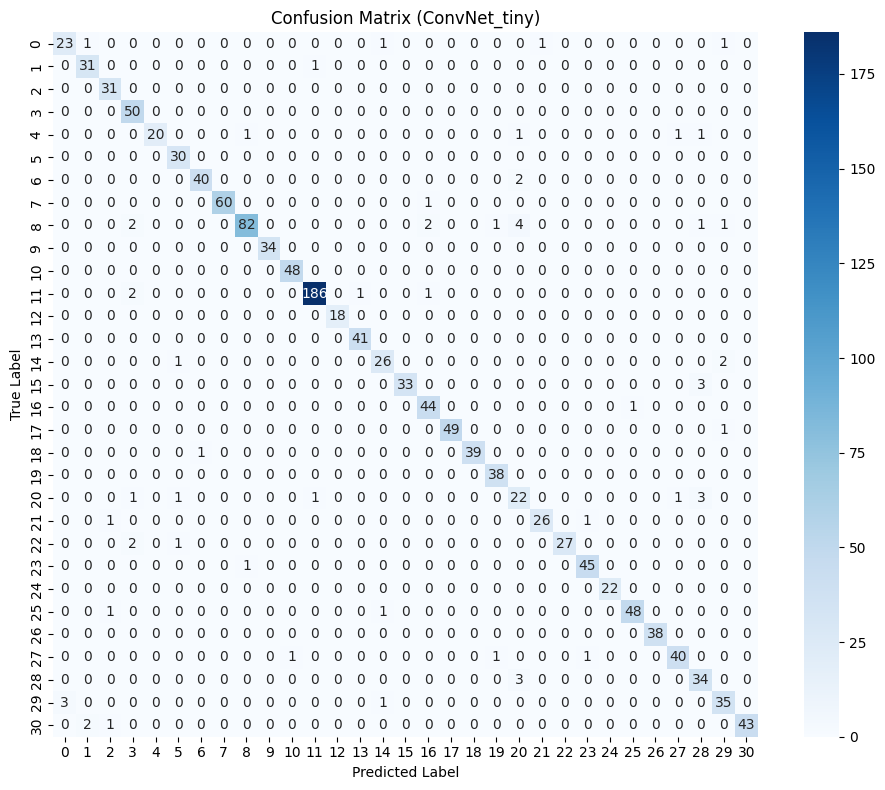

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# === Generate confusion matrix ===
cm = confusion_matrix(y_true, y_pred)
num_classes = cm.shape[0]

# === Plot ===
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=np.arange(num_classes),
            yticklabels=np.arange(num_classes),
            linewidths=0, linecolor='white', square=True)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (ConvNet_tiny)")
plt.tight_layout()
plt.show()